# yfinance Library Assignment  

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [3]:
def download_historical_data(symbol, start_date, end_date, timeframe="1d"):
    valid_timeframes = {"1d", "1wk", "1mo"}
    if timeframe not in valid_timeframes:
        raise ValueError(f"timeframe must be one of {sorted(valid_timeframes)}")

    data = yf.download(
        symbol,
        start=start_date,
        end=end_date,
        interval=timeframe,
        auto_adjust=False,
        progress=False,
    )
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data

### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


In [4]:
def plot_closing_prices(data, symbol, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))
    ax.plot(data.index, data["Close"], label=symbol)
    ax.set_title(title or f"{symbol} Closing Prices")
    ax.set_xlabel("Date")
    ax.set_ylabel("Closing Price (INR)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    return ax

### Run the functions 

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

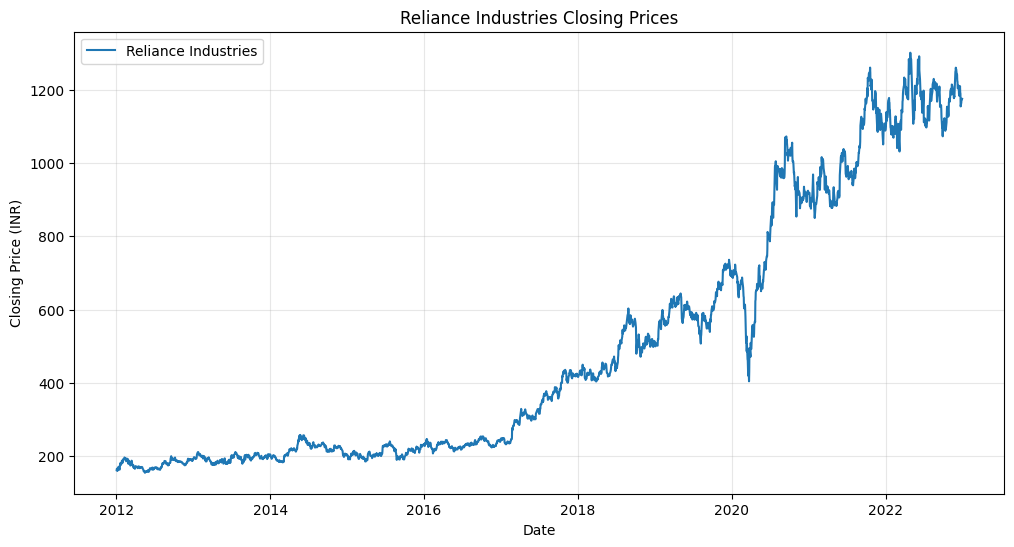

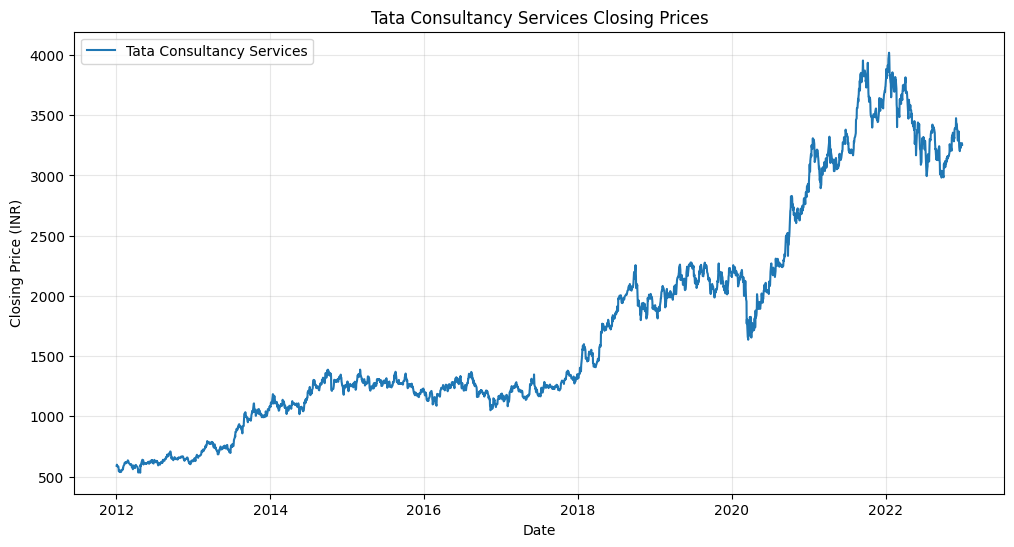

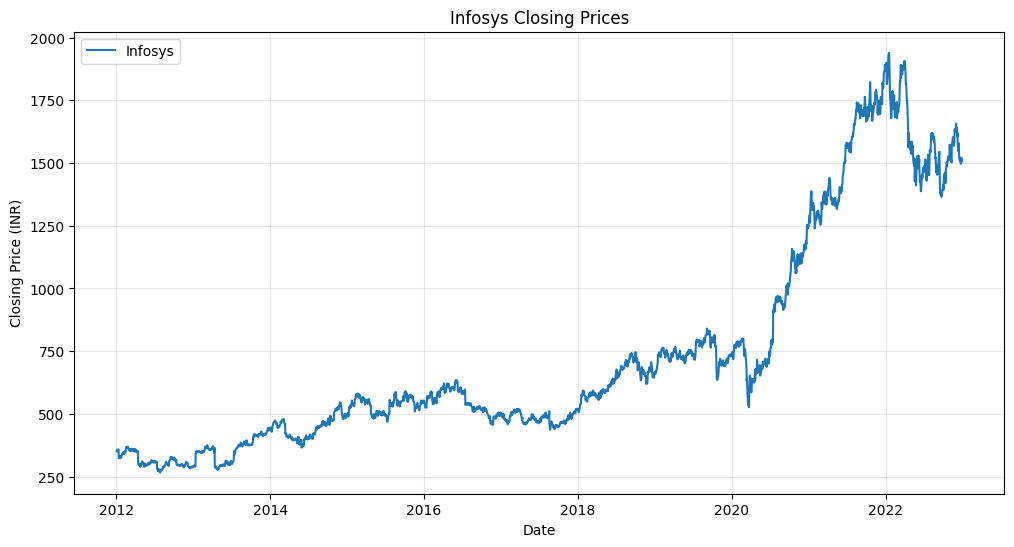

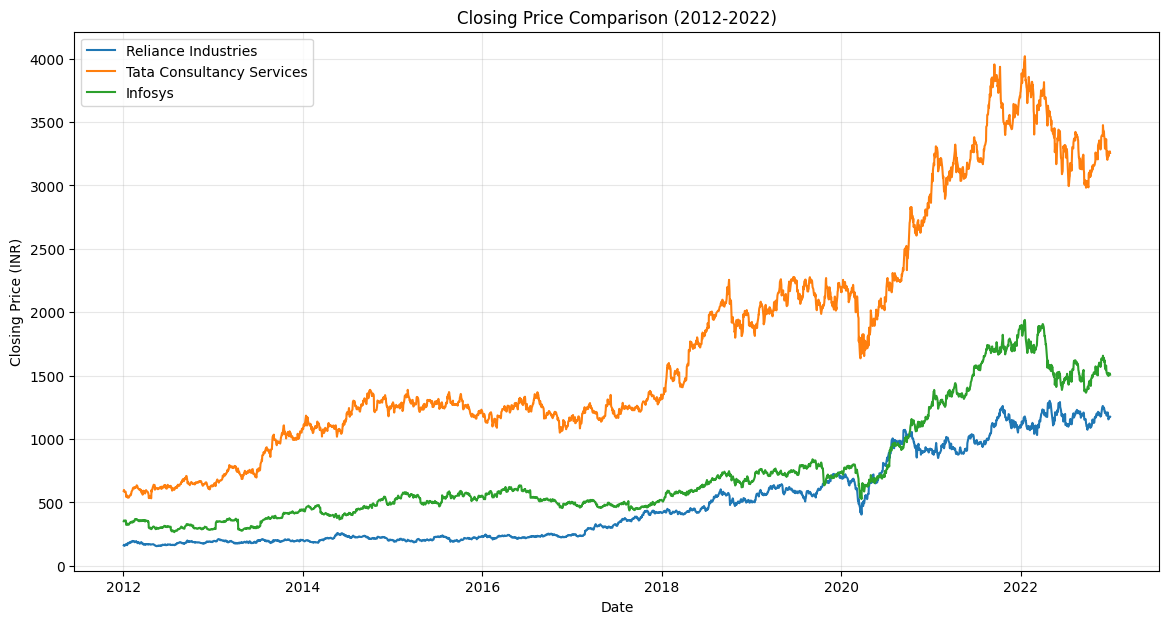

In [5]:
stocks = {
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS",
    "Infosys": "INFY.NS",
}
stock_data = {
    company: download_historical_data(ticker, "2012-01-01", "2023-01-01", "1d")
    for company, ticker in stocks.items()
}

for company, data in stock_data.items():
    plot_closing_prices(data, company)
    plt.show()

fig, ax = plt.subplots(figsize=(14, 7))
for company, data in stock_data.items():
    ax.plot(data.index, data["Close"], label=company)
ax.set_title("Closing Price Comparison (2012-2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (INR)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Technical Analysis 

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph 
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

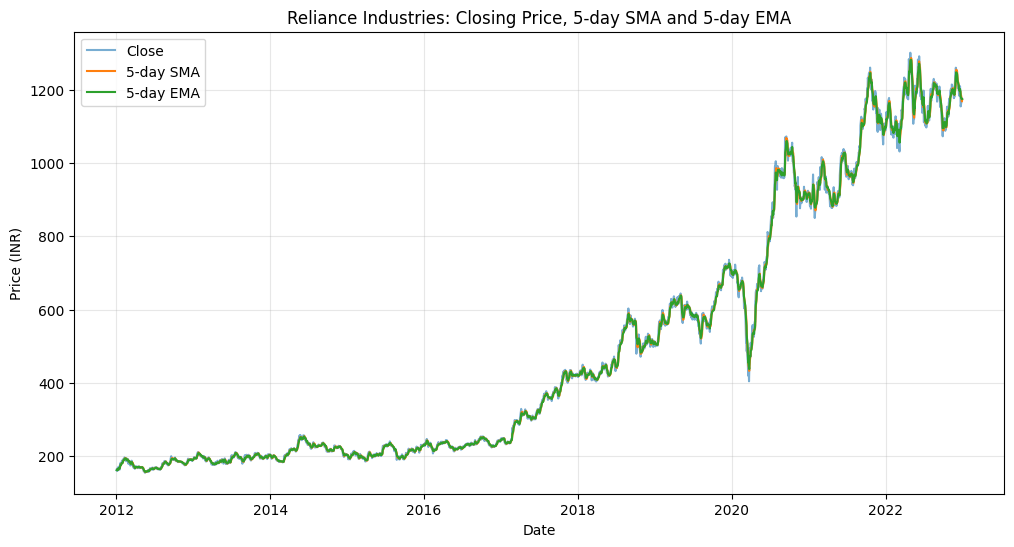

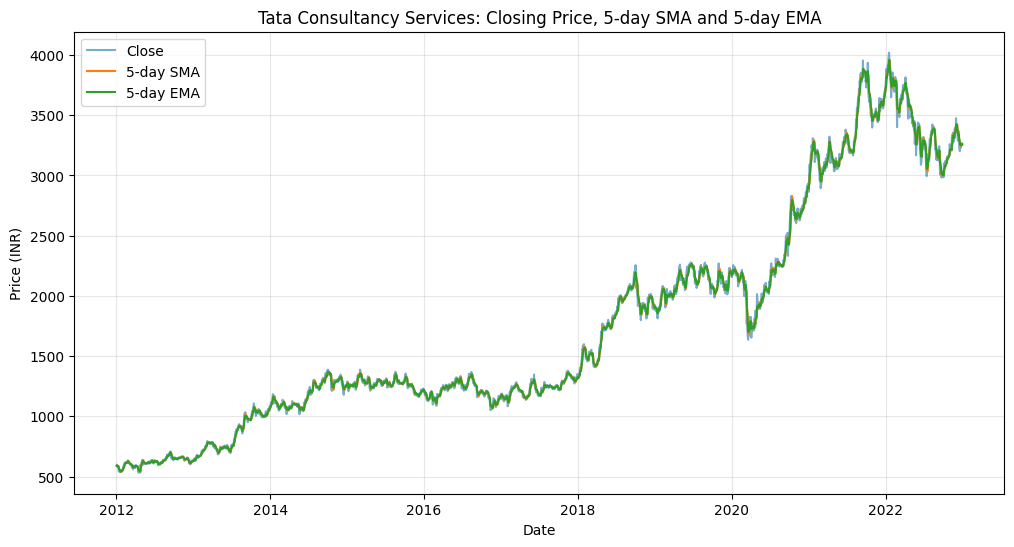

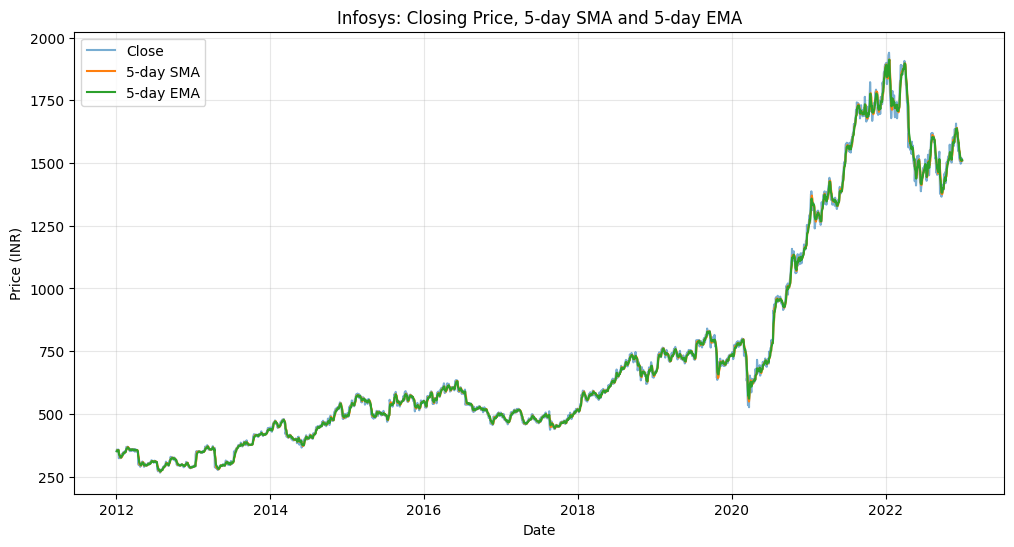

In [6]:
for company, data in stock_data.items():
    data["SMA_5"] = data["Close"].rolling(window=5).mean()
    data["EMA_5"] = data["Close"].ewm(span=5, adjust=False).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data["Close"], label="Close", alpha=0.6)
    plt.plot(data.index, data["SMA_5"], label="5-day SMA")
    plt.plot(data.index, data["EMA_5"], label="5-day EMA")
    plt.title(f"{company}: Closing Price, 5-day SMA and 5-day EMA")
    plt.xlabel("Date")
    plt.ylabel("Price (INR)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

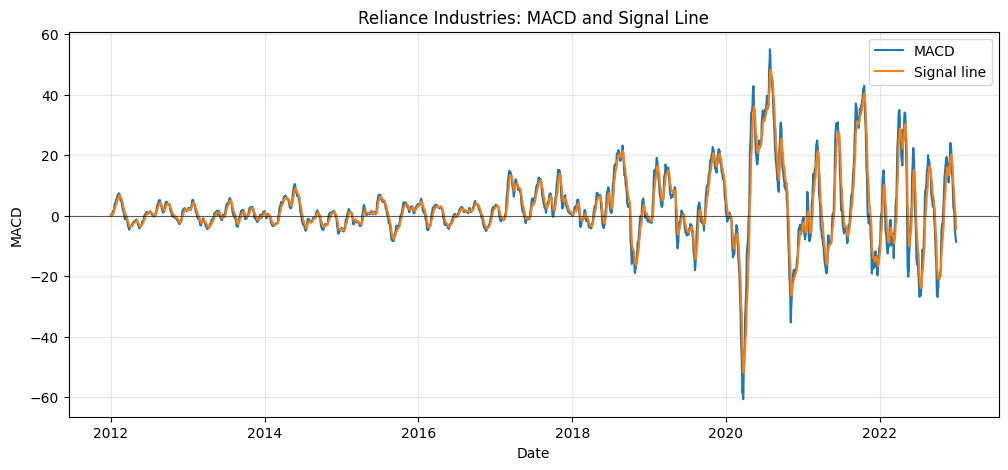

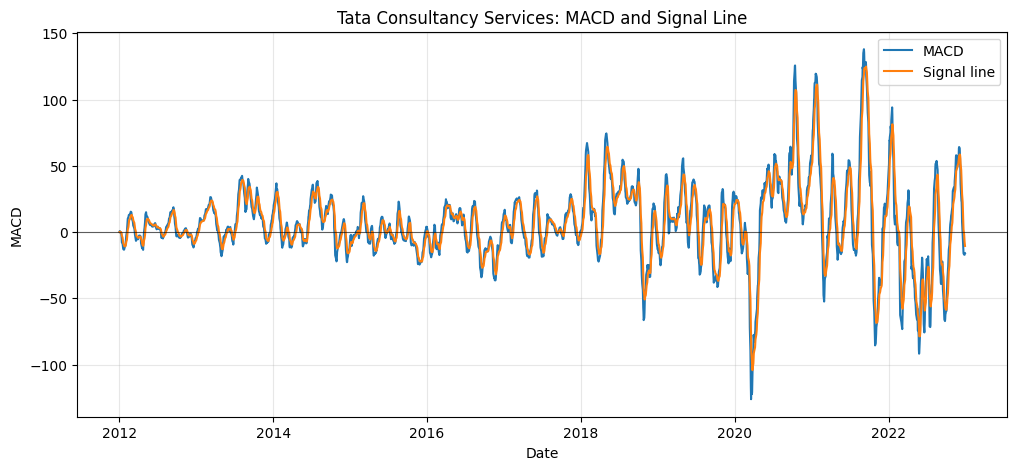

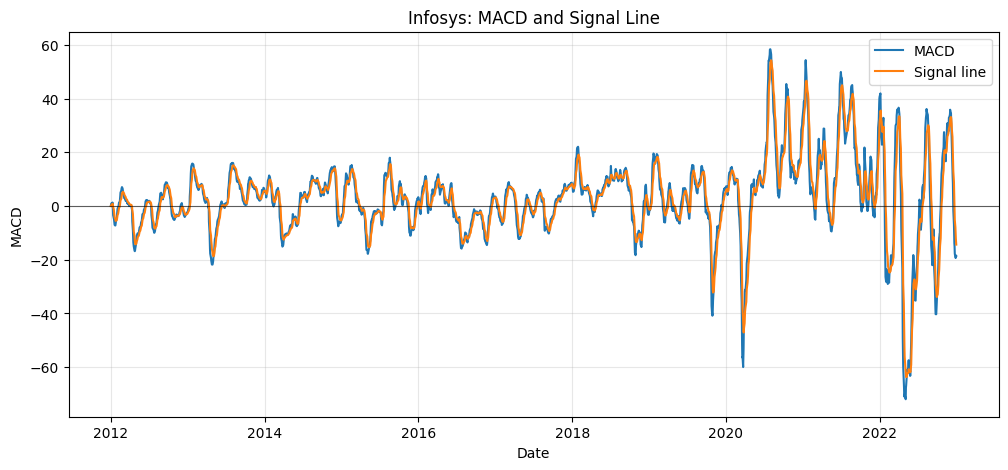

In [7]:
for company, data in stock_data.items():
    ema_12 = data["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = data["Close"].ewm(span=26, adjust=False).mean()
    data["MACD"] = ema_12 - ema_26
    data["Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()

    plt.figure(figsize=(12, 5))
    plt.plot(data.index, data["MACD"], label="MACD")
    plt.plot(data.index, data["Signal"], label="Signal line")
    plt.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    plt.title(f"{company}: MACD and Signal Line")
    plt.xlabel("Date")
    plt.ylabel("MACD")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days 
   - Also show the overbought and oversold regions 
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

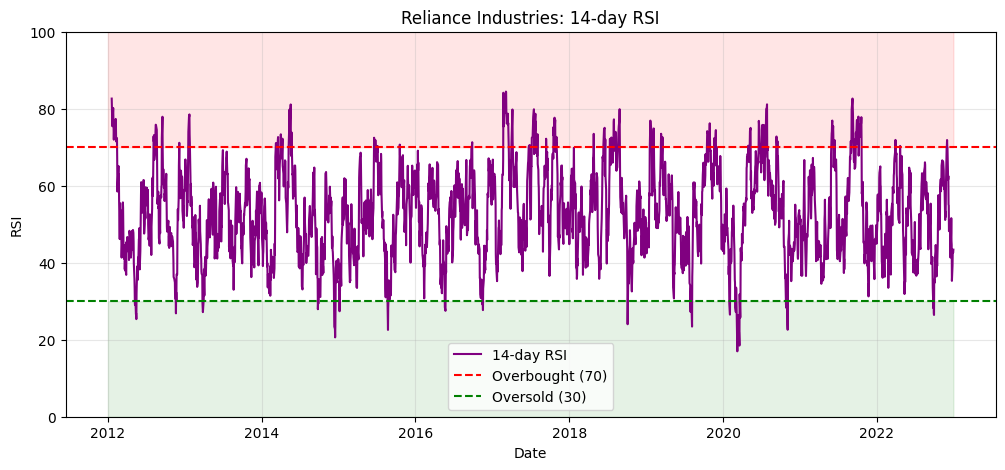

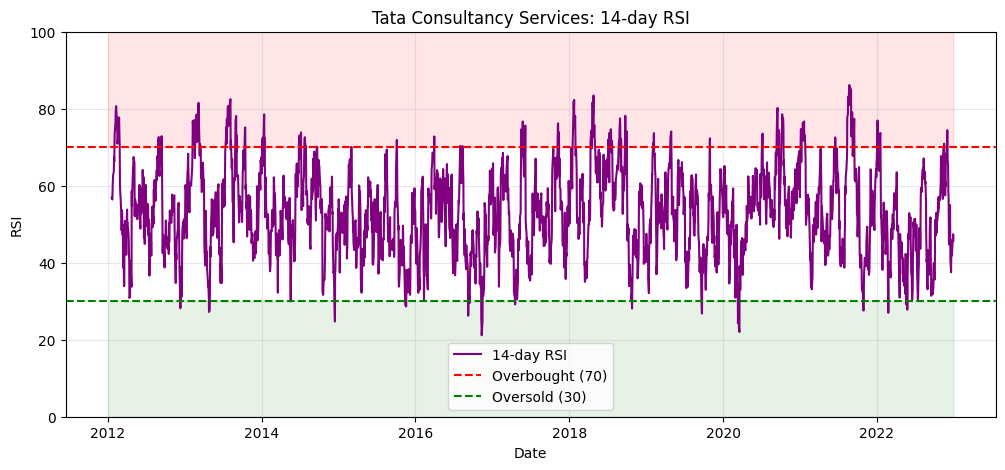

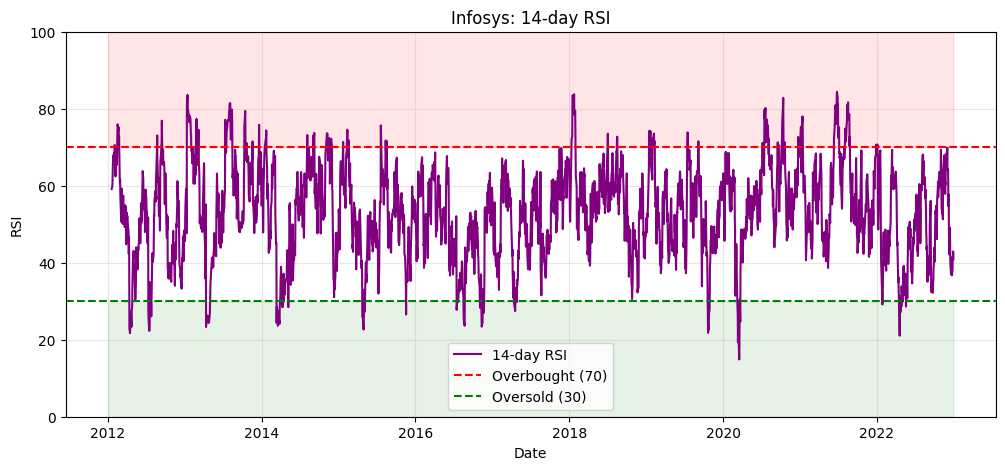

In [8]:
for company, data in stock_data.items():
    price_change = data["Close"].diff()
    gains = price_change.clip(lower=0)
    losses = -price_change.clip(upper=0)
    average_gain = gains.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    average_loss = losses.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    relative_strength = average_gain / average_loss
    data["RSI_14"] = 100 - (100 / (1 + relative_strength))

    plt.figure(figsize=(12, 5))
    plt.plot(data.index, data["RSI_14"], label="14-day RSI", color="purple")
    plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
    plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
    plt.fill_between(data.index, 70, 100, color="red", alpha=0.1)
    plt.fill_between(data.index, 0, 30, color="green", alpha=0.1)
    plt.ylim(0, 100)
    plt.title(f"{company}: 14-day RSI")
    plt.xlabel("Date")
    plt.ylabel("RSI")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

### Summarize your analysis

In [9]:
for company, data in stock_data.items():
    data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()
    data["EMA_50"] = data["Close"].ewm(span=50, adjust=False).mean()
    data["EMA_200"] = data["Close"].ewm(span=200, adjust=False).mean()

    latest = data.dropna(subset=["Close", "MACD", "Signal", "RSI_14"]).iloc[-1]
    recent_return = (latest["Close"] / data["Close"].dropna().iloc[-6] - 1) * 100
    high_52_week = data["Close"].dropna().tail(252).max()
    near_52_week_high = latest["Close"] >= 0.95 * high_52_week
    above_emas = [
        period
        for period in (20, 50, 200)
        if latest["Close"] > latest[f"EMA_{period}"]
    ]

    if len(above_emas) == 3:
        trend_text = "remains in a strong uptrend, trading above its 20, 50 and 200-day EMAs"
    elif latest["Close"] > latest["EMA_200"]:
        trend_text = "continues to trade above its 200-day EMA, keeping the broader trend constructive"
    elif not above_emas:
        trend_text = "remains under pressure, trading below its 20, 50 and 200-day EMAs"
    else:
        periods = ", ".join(str(period) for period in above_emas)
        trend_text = f"shows mixed momentum while holding above its {periods}-day EMA levels"

    if latest["MACD"] > latest["Signal"]:
        momentum_text = "MACD remains above the signal line, indicating positive momentum"
    else:
        momentum_text = "MACD remains below the signal line, reflecting weak momentum"

    if latest["RSI_14"] > 70:
        rsi_text = "RSI has entered the overbought zone, so a short-term cooling-off phase is worth tracking"
    elif latest["RSI_14"] < 30:
        rsi_text = "RSI has entered the oversold zone, making a possible technical rebound worth tracking"
    else:
        rsi_text = f"RSI is neutral at {latest['RSI_14']:.1f}, leaving room for the current move to develop"

    high_text = " The stock is also hovering near its 52-week high." if near_52_week_high else ""
    move_text = "gained" if recent_return >= 0 else "declined"
    print(
        f"{company}: {company} {trend_text}. Over the latest five sessions of 2022, "
        f"the stock {move_text} {abs(recent_return):.2f}%. {momentum_text}. {rsi_text}.{high_text}\n"
    )

Reliance Industries: Reliance Industries continues to trade above its 200-day EMA, keeping the broader trend constructive. Over the latest five sessions of 2022, the stock gained 1.80%. MACD remains below the signal line, reflecting weak momentum. RSI is neutral at 43.4, leaving room for the current move to develop.

Tata Consultancy Services: Tata Consultancy Services remains under pressure, trading below its 20, 50 and 200-day EMAs. Over the latest five sessions of 2022, the stock gained 0.88%. MACD remains below the signal line, reflecting weak momentum. RSI is neutral at 45.8, leaving room for the current move to develop.

Infosys: Infosys remains under pressure, trading below its 20, 50 and 200-day EMAs. Over the latest five sessions of 2022, the stock gained 0.74%. MACD remains below the signal line, reflecting weak momentum. RSI is neutral at 40.9, leaving room for the current move to develop.

